### Zomato Data Analysis

In [238]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load data

In [239]:
zomato_data = pd.read_csv("../dataset/zomato.csv", encoding="latin")

In [240]:
zomato_data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

#### 📊 Exploratory Analysis

##### Top Cities with Most Restaurants

In [241]:
top_10_city = zomato_data.aggregate('City').value_counts().reset_index().head(10)
top_10_city

,City,count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25
5,Bhubaneshwar,21
6,Amritsar,21
7,Ahmedabad,21
8,Lucknow,21
9,Guwahati,21


([<matplotlib.patches.Wedge at 0x174c44410>,
 [Text(-0.5885541912335229, 0.9293029452129451, 'New Delhi'),
  Text(-0.006008343617810127, -1.099983590698957, 'Gurgaon'),
  Text(0.8279428579856501, -0.7242310569911745, 'Noida'),
  Text(1.078210030606925, -0.2178603449428412, 'Faridabad'),
  Text(1.0953795609912533, -0.10071552691918685, 'Ghaziabad'),
  Text(1.0970106181828267, -0.08104136964620427, 'Bhubaneshwar'),
  Text(1.0981912938727971, -0.06305459588318775, 'Amritsar'),
  Text(1.0990770752265593, -0.045050890240177645, 'Ahmedabad'),
  Text(1.0996677243876434, -0.027035087203528485, 'Lucknow'),
  Text(1.0999630784532353, -0.00901254901134464, 'Guwahati')],
 [Text(-0.32102955885464884, 0.5068925155706973, '67.97%'),
  Text(-0.0032772783369873415, -0.5999910494721583, '13.88%'),
  Text(0.4516051952649, -0.39503512199518603, '13.41%'),
  Text(0.5881145621492319, -0.11883291542336792, '3.12%'),
  Text(0.5974797605406835, -0.054935741955920096, '0.31%'),
  Text(0.5983694280997236, -0.044

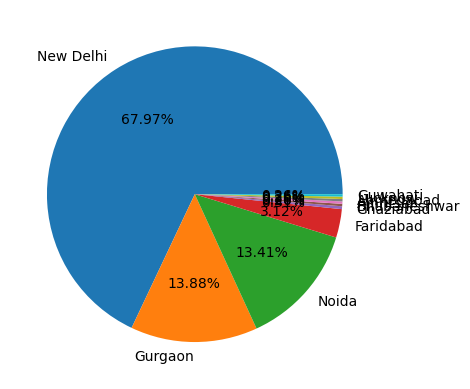

In [242]:
plt.pie(data=top_10_city,labels=top_10_city['City'].values, x=top_10_city['count'].values, autopct="%1.2f%%")

In [243]:
print(f"{top_10_city.loc[0, 'City']} has the highest number of restaurants with {top_10_city.loc[0, 'count']} establishments.")

New Delhi has the highest number of restaurants with 5473 establishments.


#### What are the top 10 cuisines across all restaurants?

In [244]:
zomato_data['Cuisines'].fillna(zomato_data['Cuisines'].value_counts().index[0], inplace=True)

/var/folders/g2/c4ppjm_x53lfmhpz_sqp533r0000gn/T/ipykernel_89946/2808774564.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  zomato_data['Cuisines'].fillna(zomato_data['Cuisines'].value_counts().index[0], inplace=True)


In [245]:
cuisines_count = zomato_data['Cuisines'].str.split(",").explode().value_counts().reset_index()

In [246]:
cuisines_count["Cuisines"] = cuisines_count['Cuisines'].str.strip()

In [247]:
top_5_cuisines = cuisines_count.groupby("Cuisines").sum().sort_values(by='count', ascending=False).head()
top_5_cuisines

,count
Cuisines,
North Indian,3969
Chinese,2735
Fast Food,1986
Mughlai,995
Italian,764


/var/folders/g2/c4ppjm_x53lfmhpz_sqp533r0000gn/T/ipykernel_89946/2256231268.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_5_cuisines, x='Cuisines', y='count', palette=palette)


<Axes: xlabel='Cuisines', ylabel='count'>

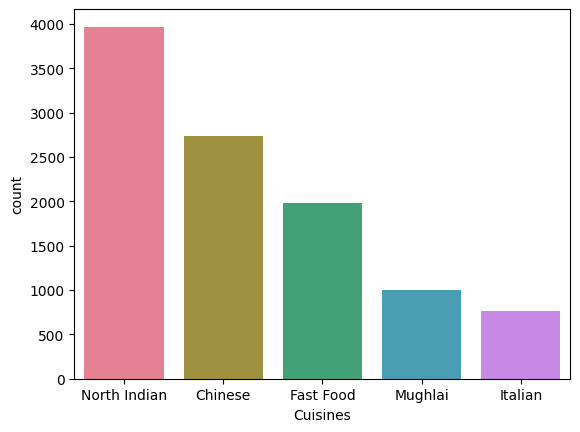

In [248]:
palette = sns.color_palette('husl', 5)
sns.barplot(top_5_cuisines, x='Cuisines', y='count', palette=palette)

#### What is the average cost for two people in different cities/countries?

In [249]:
def add_rating(rate):
    if rate >= 4.5:
        return "Excellent";
    elif rate >= 4:
        return "Very Good"
    elif rate >= 3:
        return "Good"
    else:
        return "Bad"

In [250]:
zomato_data['rating'] = zomato_data['Aggregate rating'].apply(add_rating)

#### How are the ratings distributed (Excellent, Very Good, Good, etc.)?

In [251]:
rating_distribution = zomato_data['rating'].value_counts()
rating_distribution

rating
Good         4590
Bad          3581
Very Good    1079
Excellent     301
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x174d88050>,
 [Text(0.06707613557864979, 1.0979530008319276, 'Good'),
  Text(-0.5417279373850357, -0.9573561729348984, 'Bad'),
  Text(0.9360896036067041, -0.5776991033569671, 'Very Good'),
  Text(1.0946130432768613, -0.10873033379958184, 'Excellent')],
 [Text(0.03658698304289988, 0.5988834549992331, '48.06%'),
  Text(-0.29548796584638304, -0.5221942761463081, '37.49%'),
  Text(0.5105943292400204, -0.31510860183107287, '11.30%'),
  Text(0.597061659969197, -0.05930745479977191, '3.15%')])

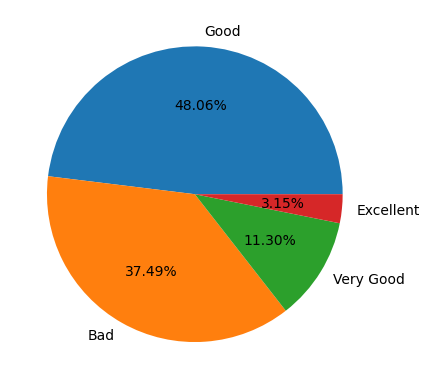

In [252]:
plt.pie(labels=rating_distribution.index, x=rating_distribution.values, autopct="%1.2f%%")

#### Do restaurants with more votes tend to have higher ratings?

In [253]:
zomato_data[["Restaurant ID", "Votes", "Aggregate rating"]]

,Restaurant ID,Votes,Aggregate rating
0,6317637,314,4.8
1,6304287,591,4.5
2,6300002,270,4.4
3,6318506,365,4.9
4,6314302,229,4.8
...,...,...,...
9546,5915730,788,4.1
9547,5908749,1034,4.2
9548,5915807,661,3.7
9549,5916112,901,4.0


In [254]:
# Display correlation between Votes and Aggregate rating
correlation = zomato_data['Votes'].corr(zomato_data['Aggregate rating'])
print(f"Correlation between Votes and Aggregate rating: {correlation:.2f}")

# Conclusion
print("No, a higher number of votes does not necessarily mean a higher rating. The correlation is weak.")

Correlation between Votes and Aggregate rating: 0.31
No, a higher number of votes does not necessarily mean a higher rating. The correlation is weak.


### 🍽 Business Insights

#### Do restaurants offering online delivery have higher ratings compared to those that don’t?

In [255]:
online_delivery = zomato_data.groupby('Has Online delivery')['rating'].value_counts().reset_index()
online_delivery

,Has Online delivery,rating,count
0,No,Good,3074
1,No,Bad,2962
2,No,Very Good,802
3,No,Excellent,262
4,Yes,Good,1516
5,Yes,Bad,619
6,Yes,Very Good,277
7,Yes,Excellent,39


#### Do restaurants that allow table booking receive better ratings on average?

In [256]:
avg_ratings = zomato_data.groupby("Has Table booking")["Aggregate rating"].mean()
avg_ratings

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64

#### Compare ratings between high-cost and budget restaurants.

In [257]:
# Create cost categories
def cost_category(x):
    if x <= 500:
        return "Budget"
    elif x <= 1500:
        return "Mid-range"
    else:
        return "High-cost"

zomato_data["Cost Category"] = zomato_data["Average Cost for two"].apply(cost_category)

# Group and compare average ratings
cost_rating_comparison = zomato_data.groupby("Cost Category")["Aggregate rating"].mean().reset_index()

cost_rating_comparison


,Cost Category,Aggregate rating
0,Budget,2.322423
1,High-cost,3.698630
2,Mid-range,3.180124


In [258]:
zomato_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

#### Which cuisine types are most associated with high ratings?

In [259]:
# cuisine_ratings = (
#     zomato_data.dropna(subset=["Address"])
#     .assign(Address_New=zomato_data["Address"].str.split(","))
#     .explode("Address_New")
# )
# cuisine_ratings.head(10)

In [264]:
cuisine_ratings = (
    zomato_data.dropna(subset=["Cuisines"])
    .assign(Cuisine=zomato_data["Cuisines"].str.split(","))
    .explode("Cuisine")
)
cuisine_ratings.groupby("Cuisine")["Aggregate rating"].mean().reset_index().sort_values(ascending=False, by="Aggregate rating").head(10)

,Cuisine,Aggregate rating
236,Sunda,4.900000
226,Scottish,4.700000
25,Bí_rek,4.700000
154,Cajun,4.700000
30,Caribbean,4.666667
238,Taiwanese,4.650000
167,Filipino,4.616667
221,Ramen,4.600000
215,Persian,4.600000
248,World Cuisine,4.500000


#### Which localities have the most highly-rated restaurants in a given city?

In [276]:
zomato_data.dropna(subset='Locality Verbose').assign(Locality=zomato_data['Locality Verbose'].str.split(",")).explode("Locality").groupby("Locality")['Aggregate rating'].mean().reset_index(name='Average rating').sort_values(by='Average rating', ascending=False).head(100)

,Locality,Average rating
910,Kenwood,4.9
717,Fort Street,4.9
772,Gíçvea,4.9
805,Hotel Clarks Amer,4.9
1509,Venetian Village,4.9
...,...,...
356,Tourist Club Area (Al Zahiyah),4.6
200,Maddilapalem,4.6
1096,Nicolway Shopping Centre,4.6
545,Cavelossim,4.6


#### 🌍 Geographical Analysis

#### Which countries contribute the most data to the dataset?

In [283]:
zomato_data['Country Code'].value_counts().reset_index()

,Country Code,count
0,1,8652
1,216,434
2,215,80
3,30,60
4,214,60
5,189,60
6,148,40
7,208,34
8,14,24
9,162,22


#### Compare food affordability across countries using Average Cost for two.

In [287]:
zomato_data.groupby('Country Code')['Average Cost for two'].mean().reset_index(name='Average Cost').sort_values(by="Average Cost", ascending=False)

,Country Code,Average Cost
4,94,281190.476190
10,191,2375.000000
6,162,1606.818182
0,1,623.370319
9,189,419.733333
7,166,223.750000
12,214,166.416667
8,184,155.750000
2,30,134.666667
11,208,84.852941


#### What are the top-rated restaurants in each country?

In [294]:
zomato_data.groupby('Country Code')["Restaurant Name"] 

In [289]:
zomato_data

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,rating,Cost Category
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,No,No,No,3,4.8,Dark Green,Excellent,314,Excellent,Mid-range
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,No,No,No,3,4.5,Dark Green,Excellent,591,Excellent,Mid-range
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,No,No,No,4,4.4,Green,Very Good,270,Very Good,High-cost
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,4,4.9,Dark Green,Excellent,365,Excellent,Mid-range
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,No,No,No,4,4.8,Dark Green,Excellent,229,Excellent,Mid-range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,No,No,No,3,4.1,Green,Very Good,788,Very Good,Budget
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,No,No,No,3,4.2,Green,Very Good,1034,Very Good,Budget
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,No,No,No,4,3.7,Yellow,Good,661,Good,Budget
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,No,No,No,4,4.0,Green,Very Good,901,Very Good,Budget
